# UnlimitedOCR demo

This notebook uses the high-level `UnlimitedOCR` API. No model, library, or Metal resource paths need to be configured here; the package resolves local artifacts or downloads the model into its cache on first use.


In [1]:
from pathlib import Path
from IPython.display import display
from PIL import Image
from unlimitedocr_c import UnlimitedOCR

ocr = UnlimitedOCR(quant="q4", force_reconvert=True)
#ocr = UnlimitedOCR()
print('model:', ocr.model_path)

/Users/mascit/projects/unlimitedocr.c/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 111212.61it/s]


model: /Users/mascit/Library/Caches/unlimitedocr/unlimitedocr-q4.uocr
  warmup: compiling Metal pipelines... done
model: /Users/mascit/Library/Caches/unlimitedocr/unlimitedocr-q4.uocr


In [8]:
IMAGE_PATH = Path('../docs/test.png')
IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-07-05 at 12.42.28.png')
IMAGE_PATH = Path('/Users/mascit/Downloads/gibCover_6a3a41f4-5174-4e68-bffc-00e50ad30127_big_20260630134958_webp.webp')
IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-07-05 at 12.49.33.png')
IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-07-07 at 20.41.45.png')
IMAGE_PATH = Path('/Users/mascit/Downloads/gibCover_6a3a41e3-60f0-42ca-b418-00110ad300b2_big_20260630131113_webp.webp')
IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-06-26 at 17.35.54.png')

## Input image


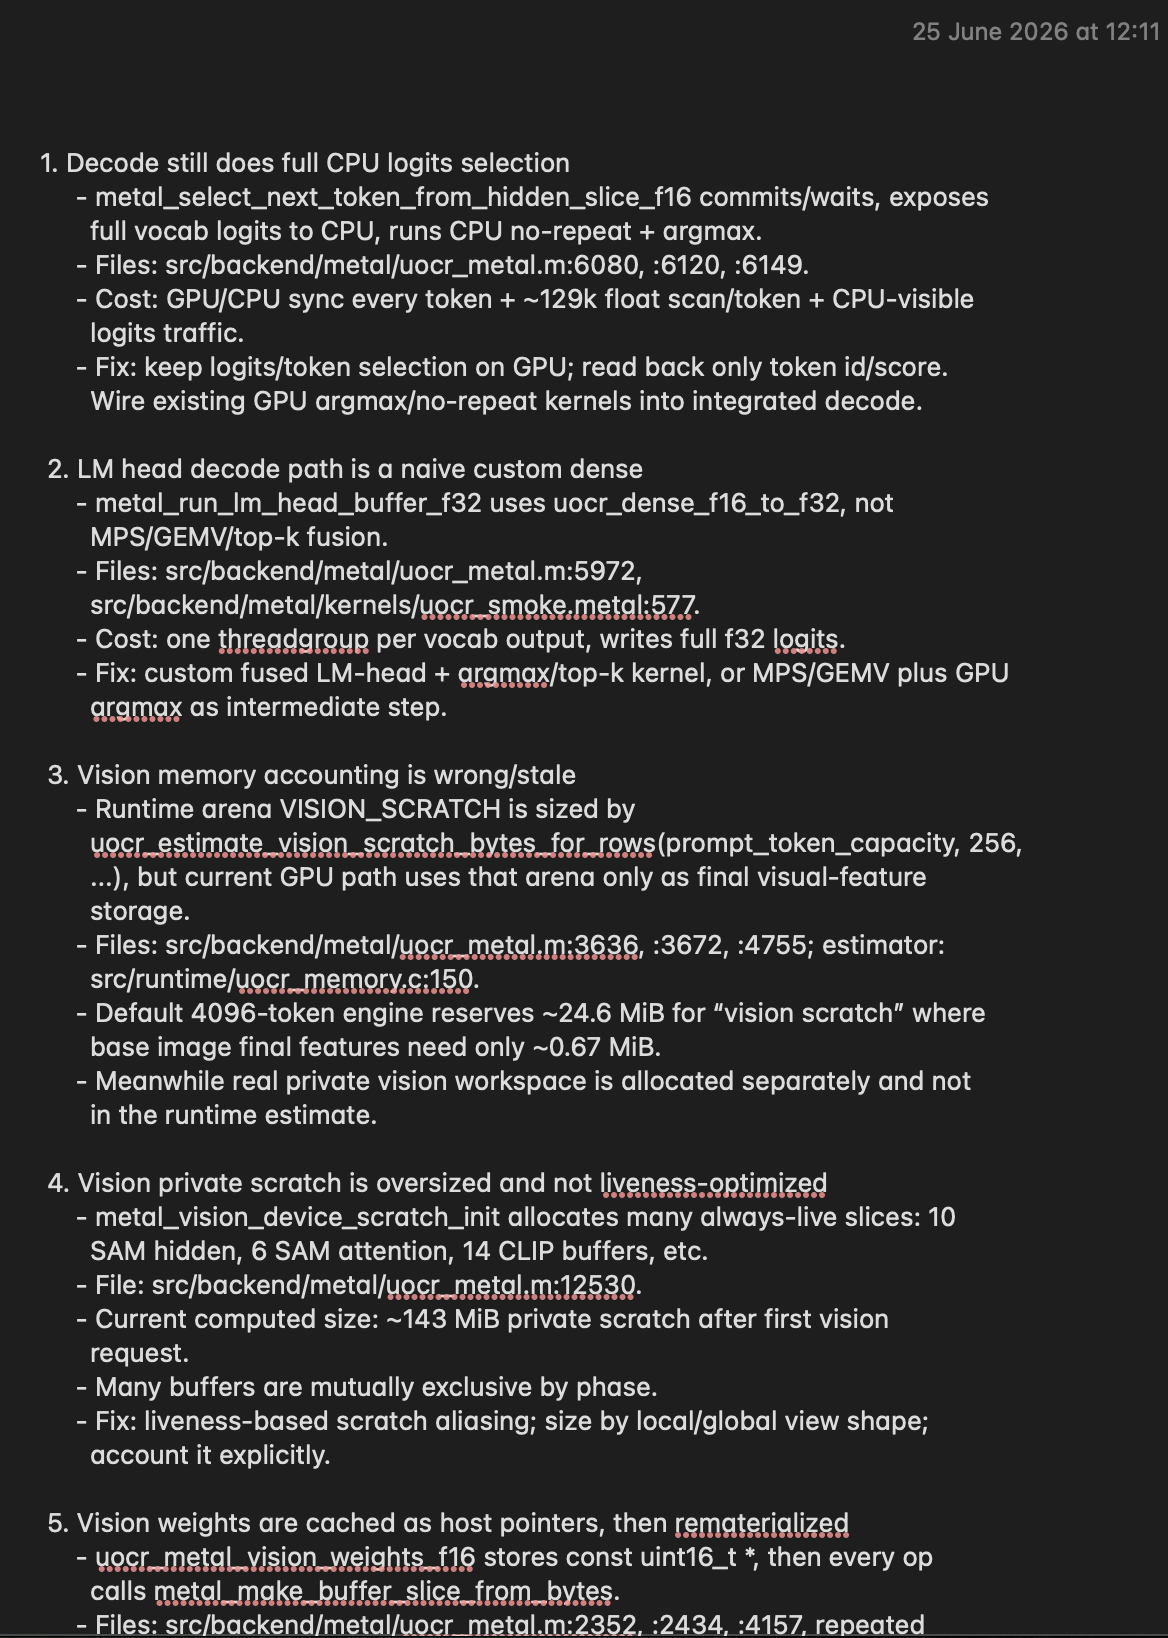

In [9]:
image = Image.open(IMAGE_PATH)
#image.thumbnail((512, 512))
display(image)

## Run OCR


In [ ]:
text = ocr.generate(IMAGE_PATH, profile='base')
print(text)

<|det|>header [778, 10, 999, 27]<|/det|>25 June 2026 at 12:11
<|det|>text [30, 89, 490, 109]<|/det|>1. Decode still does full CPU logits selection
<|det|>text [60, 111, 848, 150]<|/det|>- metal_select_next_token_from_hidden_slice_f16 commits/waits, exposes full vocab logits to CPU, runs CPU no-repeat + argmax.
<|det|>text [61, 152, 694, 171]<|/det|>- Files: src/backend/metal/uocr_metal.m:6080, :6120, :6149.
<|det|>text [61, 173, 835, 211]<|/det|>- Cost: GPU/CPU sync every token + ~129k float scan/token + CPU-visible logits traffic.
<|det|>text [61, 214, 812, 255]<|/det|>- Fix: keep logits/token selection on GPU; read back only token id/score. Wire existing GPU argmax/no-repeat kernels into integrated decode.
<|det|>text [36, 277, 553, 295]<|/det|>2. LM head decode path is a naive custom dense
<|det|>text [61, 298, 767, 336]<|/det|>- metal_run_lm_head_buffer_f32 uses uocr_dense_f16_to_f32, not MPS/GEMV/top-k fusion.
<|det|>text [61, 339, 601, 380]<|/det|>- Files: src/backend/metal/uocr_